# 🏔️ Ridge Regression (L2 Regularization)

## Overview
Ridge Regression is a regularized version of Linear Regression that adds an **L2 penalty** to the loss function to prevent overfitting and handle multicollinearity.

### Ordinary Linear Regression Loss:
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### Ridge Regression Loss (L2 Regularization):
$$\text{Loss}_{\text{Ridge}} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

- $\alpha$ (alpha) — regularization strength (hyperparameter)
- $\alpha = 0$ → ordinary linear regression
- $\alpha \to \infty$ → all coefficients shrink toward zero

---
### 📚 Topics Covered
1. Intuition & Math behind Ridge
2. The effect of alpha on coefficients
3. Multicollinearity — why Ridge helps
4. Ridge vs OLS comparison
5. Model Evaluation (MSE, R²)
6. Hyperparameter Tuning with Cross-Validation (`RidgeCV`)
7. Real-world dataset application
8. Feature importance via Ridge coefficients
9. Ridge vs Lasso vs ElasticNet comparison


## 1. 📦 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, RidgeCV, LinearRegression, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing, make_regression

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('✅ Libraries imported successfully!')
print(f'NumPy   : {np.__version__}')
print(f'Pandas  : {pd.__version__}')

✅ Libraries imported successfully!
NumPy   : 1.26.4
Pandas  : 2.3.3


## 2. 🧠 Intuition — What Does Ridge Actually Do?

Ridge **shrinks** coefficients toward zero (but never exactly zero). It trades a little bias for a large reduction in variance.

In [2]:
# Generate a regression dataset with many features (some noisy)
np.random.seed(42)
X, y, true_coefs = make_regression(
    n_samples=200,
    n_features=20,
    n_informative=10,
    noise=30,
    coef=True,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Dataset  : {X.shape[0]} samples, {X.shape[1]} features')
print(f'Train    : {X_train.shape[0]} samples')
print(f'Test     : {X_test.shape[0]} samples')
print(f'\nTrue informative coefficients (non-zero): {np.sum(true_coefs != 0)}')

Dataset  : 200 samples, 20 features
Train    : 160 samples
Test     : 40 samples

True informative coefficients (non-zero): 10


## 3. 📉 Effect of Alpha on Coefficients (Ridge Path)

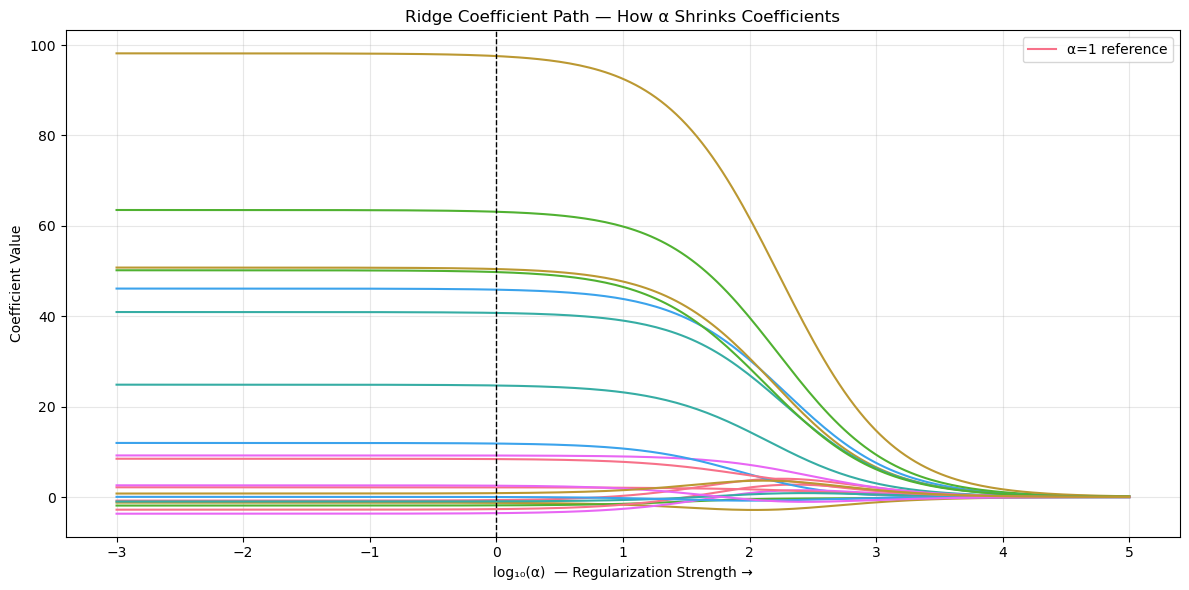

📌 As α increases (right), all coefficients shrink toward zero.
   Small α → OLS-like, Large α → heavy regularization


In [3]:
alphas = np.logspace(-3, 5, 200)
coef_paths = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_sc, y_train)
    coef_paths.append(ridge.coef_)

coef_paths = np.array(coef_paths)

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(np.log10(alphas), coef_paths[:, i], linewidth=1.5)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1, label='α=1')
plt.xlabel('log₁₀(α)  — Regularization Strength →')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Path — How α Shrinks Coefficients')
plt.legend(['α=1 reference'], loc='upper right')
plt.tight_layout()
plt.show()

print('📌 As α increases (right), all coefficients shrink toward zero.')
print('   Small α → OLS-like, Large α → heavy regularization')

## 4. ⚡ Multicollinearity — Where Ridge Really Shines

True coefficients : [3.0,  3.0,  2.0]
OLS coefficients  : [-4.327 10.891  1.675]
Ridge coefficients: [2.416 4.121 1.683]

📌 OLS blows up under multicollinearity.
   Ridge distributes weight more evenly and stays stable.


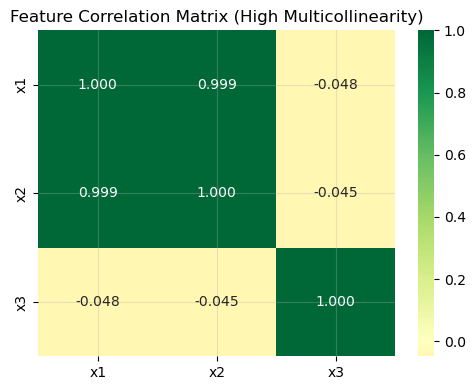

In [4]:
# Create a dataset with high multicollinearity
np.random.seed(0)
n = 150
x1 = np.random.randn(n)
x2 = x1 + np.random.randn(n) * 0.05   # x2 is almost identical to x1
x3 = np.random.randn(n)
noise = np.random.randn(n) * 2

y_mc = 3*x1 + 3*x2 + 2*x3 + noise     # true coefs: 3, 3, 2
X_mc = np.column_stack([x1, x2, x3])

X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42
)

sc_mc = StandardScaler()
X_mc_train_sc = sc_mc.fit_transform(X_mc_train)
X_mc_test_sc  = sc_mc.transform(X_mc_test)

# Fit OLS
ols = LinearRegression()
ols.fit(X_mc_train_sc, y_mc_train)

# Fit Ridge
ridge_mc = Ridge(alpha=1.0)
ridge_mc.fit(X_mc_train_sc, y_mc_train)

print('True coefficients : [3.0,  3.0,  2.0]')
print(f'OLS coefficients  : {ols.coef_.round(3)}')
print(f'Ridge coefficients: {ridge_mc.coef_.round(3)}')
print()
print('📌 OLS blows up under multicollinearity.')
print('   Ridge distributes weight more evenly and stays stable.')

# Correlation heatmap
fig, ax = plt.subplots(figsize=(5, 4))
corr = pd.DataFrame(X_mc, columns=['x1','x2','x3']).corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix (High Multicollinearity)')
plt.tight_layout()
plt.show()

## 5. ⚖️ Ridge vs Ordinary Least Squares (OLS)

Model                    Test MSE    Test R²
---------------------------------------------
OLS (α=0)                969.9150     0.9599
Ridge (α=0.01)           969.7738     0.9599
Ridge (α=0.1)            968.5135     0.9599
Ridge (α=1)              956.9449     0.9604
Ridge (α=10)             931.5615     0.9614
Ridge (α=100)           3862.9836     0.8401
Ridge (α=1000)         17671.6027     0.2687


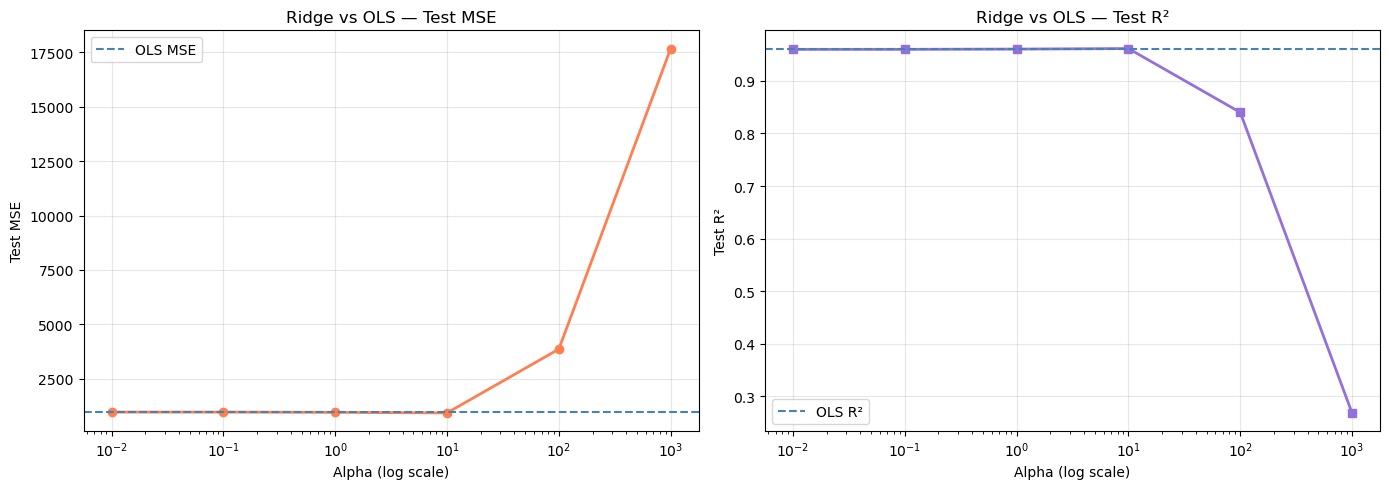

In [5]:
alphas_compare = [0.01, 0.1, 1, 10, 100, 1000]

ols_model = LinearRegression()
ols_model.fit(X_train_sc, y_train)
ols_mse   = mean_squared_error(y_test, ols_model.predict(X_test_sc))
ols_r2    = r2_score(y_test,           ols_model.predict(X_test_sc))

print(f'{'Model':<20} {'Test MSE':>12} {'Test R²':>10}')
print('-' * 45)
print(f'{'OLS (α=0)':<20} {ols_mse:>12.4f} {ols_r2:>10.4f}')

ridge_results = []
for alpha in alphas_compare:
    r = Ridge(alpha=alpha)
    r.fit(X_train_sc, y_train)
    mse = mean_squared_error(y_test, r.predict(X_test_sc))
    r2  = r2_score(y_test,           r.predict(X_test_sc))
    ridge_results.append({'Alpha': alpha, 'Test MSE': mse, 'Test R²': r2})
    print(f'{'Ridge (α='+str(alpha)+')':<20} {mse:>12.4f} {r2:>10.4f}')

# Visual comparison
df_results = pd.DataFrame(ridge_results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.semilogx(df_results['Alpha'], df_results['Test MSE'], 'o-', color='coral', linewidth=2)
ax1.axhline(y=ols_mse, color='steelblue', linestyle='--', linewidth=1.5, label='OLS MSE')
ax1.set_xlabel('Alpha (log scale)')
ax1.set_ylabel('Test MSE')
ax1.set_title('Ridge vs OLS — Test MSE')
ax1.legend()

ax2.semilogx(df_results['Alpha'], df_results['Test R²'], 's-', color='mediumpurple', linewidth=2)
ax2.axhline(y=ols_r2, color='steelblue', linestyle='--', linewidth=1.5, label='OLS R²')
ax2.set_xlabel('Alpha (log scale)')
ax2.set_ylabel('Test R²')
ax2.set_title('Ridge vs OLS — Test R²')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. 🔍 Hyperparameter Tuning with RidgeCV

✅ Best alpha found by RidgeCV : 0.869749
   Test MSE  : 958.5042
   Test MAE  : 21.1775
   Test R²   : 0.9603


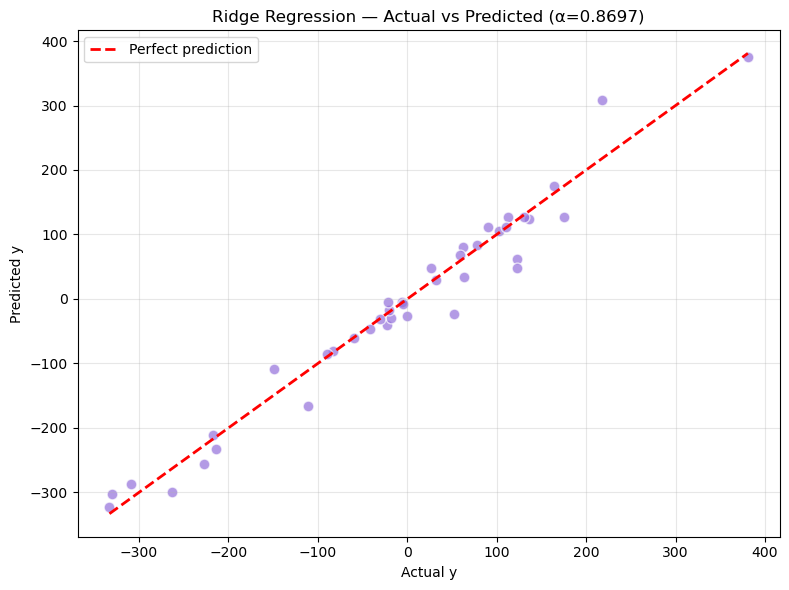

In [6]:
# RidgeCV performs Leave-One-Out or K-Fold CV internally — very efficient
alphas_grid = np.logspace(-4, 6, 100)

ridge_cv = RidgeCV(
    alphas=alphas_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error'
)
ridge_cv.fit(X_train_sc, y_train)

best_alpha = ridge_cv.alpha_
print(f'✅ Best alpha found by RidgeCV : {best_alpha:.6f}')

y_pred_cv = ridge_cv.predict(X_test_sc)
print(f'   Test MSE  : {mean_squared_error(y_test, y_pred_cv):.4f}')
print(f'   Test MAE  : {mean_absolute_error(y_test, y_pred_cv):.4f}')
print(f'   Test R²   : {r2_score(y_test, y_pred_cv):.4f}')

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cv, alpha=0.7, color='mediumpurple', edgecolors='white', s=60)
lims = [min(y_test.min(), y_pred_cv.min()), max(y_test.max(), y_pred_cv.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title(f'Ridge Regression — Actual vs Predicted (α={best_alpha:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

## 7. 🌍 Real-World Dataset — California Housing

In [9]:
import urllib.request

urllib.request.urlopen("https://www.google.com")
print("Internet is working!")

Internet is working!


In [10]:
# Load dataset
import pandas as pd

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
from sklearn.impute import SimpleImputer

# Features and target
X_h = df.drop(["median_house_value", "ocean_proximity"], axis=1)
y_h = df["median_house_value"]

# Train-test split
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h,
    y_h,
    test_size=0.2,
    random_state=42
)

# Build pipelines
ols_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RidgeCV(
        alphas=np.logspace(-4, 6, 100),
        cv=5
    ))
])

# Train
ols_pipe.fit(X_h_train, y_h_train)
ridge_pipe.fit(X_h_train, y_h_train)

# Best alpha
best_alpha_h = ridge_pipe.named_steps['model'].alpha_

# Evaluate
for name, pipe in [
    ('OLS', ols_pipe),
    (f'Ridge (α={best_alpha_h:.3f})', ridge_pipe)
]:
    preds = pipe.predict(X_h_test)

    print(
        f'{name:<30} '
        f'MSE={mean_squared_error(y_h_test, preds):.4f}  '
        f'R²={r2_score(y_h_test, preds):.4f}'
    )

OLS                            MSE=5059656033.1261  R²=0.6139
Ridge (α=14.175)               MSE=5053100735.3227  R²=0.6144


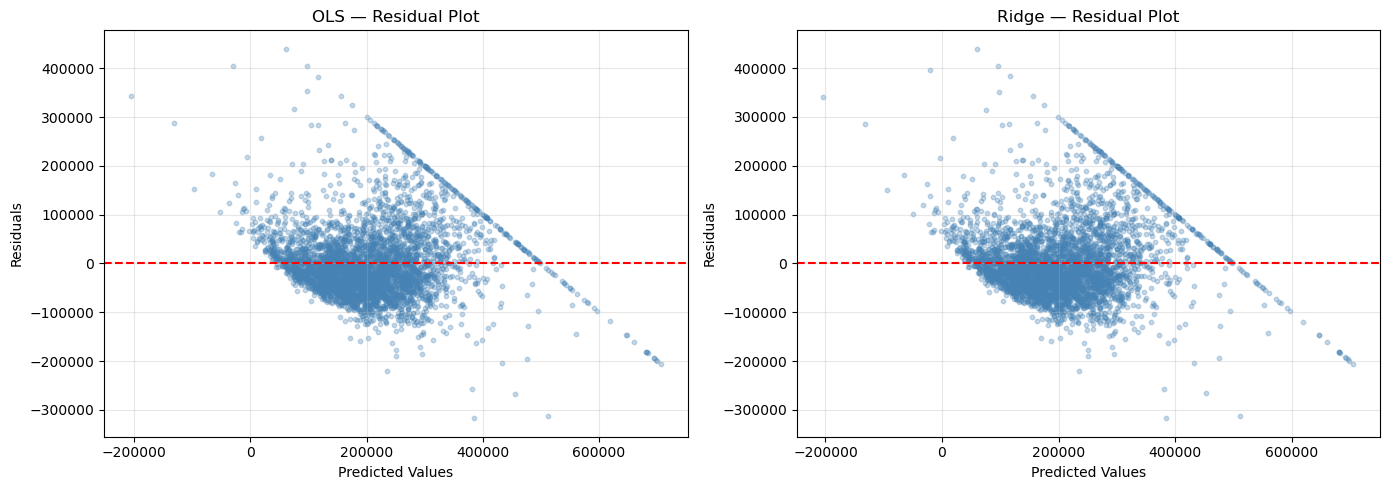

In [14]:
# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, pipe) in zip(axes, [('OLS', ols_pipe), ('Ridge', ridge_pipe)]):
    preds    = pipe.predict(X_h_test)
    residuals = y_h_test - preds
    ax.scatter(preds, residuals, alpha=0.3, s=10, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} — Residual Plot')

plt.tight_layout()
plt.show()

## 8. 📊 Feature Importance via Ridge Coefficients

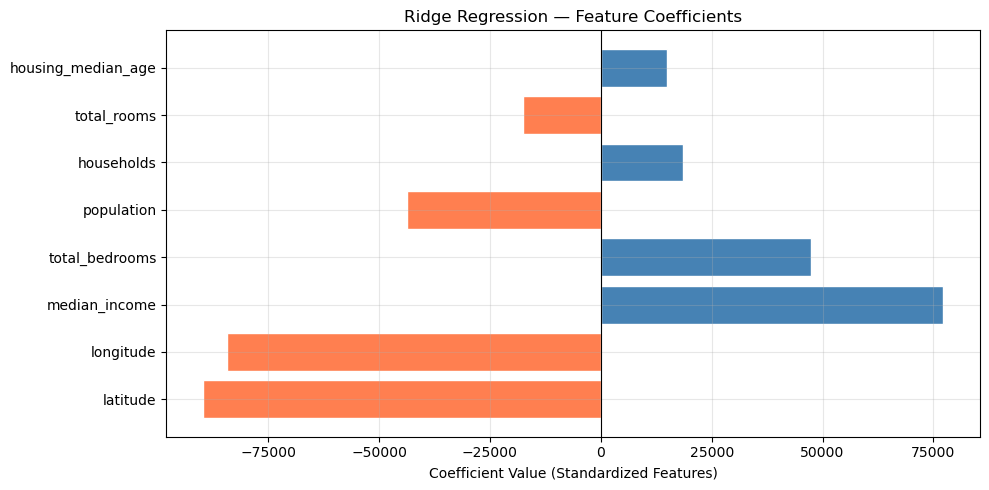


Feature Coefficients (sorted by absolute value):
           Feature  Coefficient
          latitude  -89580.8695
         longitude  -84374.2317
     median_income   77150.4669
    total_bedrooms   47381.7610
        population  -43626.1879
        households   18532.3681
       total_rooms  -17446.7608
housing_median_age   15006.3252


In [16]:
coefs = ridge_pipe.named_steps['model'].coef_

# Get feature names from X_h
feature_names = X_h.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values('Coefficient', key=abs, ascending=False)

colors = ['coral' if c < 0 else 'steelblue'
          for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 5))
plt.barh(
    coef_df['Feature'],
    coef_df['Coefficient'],
    color=colors,
    edgecolor='white'
)

plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value (Standardized Features)')
plt.title('Ridge Regression — Feature Coefficients')
plt.tight_layout()
plt.show()

print('\nFeature Coefficients (sorted by absolute value):')
print(coef_df.round(4).to_string(index=False))

## 9. ⚔️ Ridge vs Lasso vs ElasticNet

=== Model Comparison ===
     Model     Test MSE  Test R²
       OLS 5.052955e+09   0.6144
     Ridge 5.046778e+09   0.6149
     Lasso 5.052954e+09   0.6144
ElasticNet 5.030481e+09   0.6161


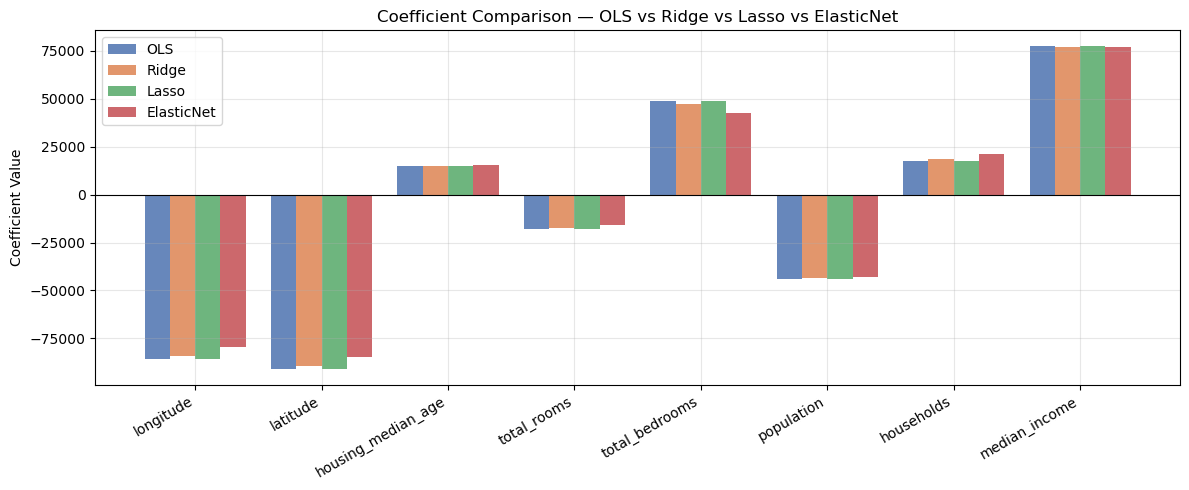


📌 Ridge  → shrinks all coefficients (never exactly zero)
📌 Lasso  → shrinks some coefficients to exactly zero (feature selection)
📌 ElasticNet → combines Ridge and Lasso penalties


In [19]:
from sklearn.impute import SimpleImputer

models = {
    'OLS':        LinearRegression(),
    'Ridge':      Ridge(alpha=best_alpha_h),
    'Lasso':      Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

# 🔥 FIX: Handle missing values BEFORE scaling
imputer = SimpleImputer(strategy='mean')

X_h_train_imp = imputer.fit_transform(X_h_train)
X_h_test_imp  = imputer.transform(X_h_test)

sc = StandardScaler()
X_h_train_sc = sc.fit_transform(X_h_train_imp)
X_h_test_sc  = sc.transform(X_h_test_imp)

comp_results = []
all_coefs = {}

for name, model in models.items():
    model.fit(X_h_train_sc, y_h_train)

    preds = model.predict(X_h_test_sc)

    mse = mean_squared_error(y_h_test, preds)
    r2 = r2_score(y_h_test, preds)

    comp_results.append({
        'Model': name,
        'Test MSE': round(mse, 4),
        'Test R²': round(r2, 4)
    })

    all_coefs[name] = model.coef_

comp_df = pd.DataFrame(comp_results)

print('=== Model Comparison ===')
print(comp_df.to_string(index=False))

# Feature names
feature_names = X_h.columns

# Coefficient comparison
coef_comp = pd.DataFrame(all_coefs, index=feature_names)

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(feature_names))
width = 0.2
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, (name, color) in enumerate(zip(models.keys(), palette)):
    ax.bar(
        x + i * width,
        coef_comp[name],
        width,
        label=name,
        color=color,
        alpha=0.85
    )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(feature_names, rotation=30, ha='right')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_ylabel('Coefficient Value')
ax.set_title('Coefficient Comparison — OLS vs Ridge vs Lasso vs ElasticNet')
ax.legend()

plt.tight_layout()
plt.show()

print('\n📌 Ridge  → shrinks all coefficients (never exactly zero)')
print('📌 Lasso  → shrinks some coefficients to exactly zero (feature selection)')
print('📌 ElasticNet → combines Ridge and Lasso penalties')

## 10. 📋 Final Summary & Key Takeaways

In [20]:
print('=' * 60)
print('        RIDGE REGRESSION — KEY TAKEAWAYS')
print('=' * 60)

takeaways = [
    ('Penalty',         'L2 — adds α × Σβⱼ² to the loss function'),
    ('Effect',          'Shrinks all coefficients toward zero (never exactly 0)'),
    ('Multicollinearity','Stabilizes unstable OLS estimates under correlated features'),
    ('Overfitting',     'Reduces variance at the cost of a small bias increase'),
    ('Alpha',           'Higher α → stronger shrinkage → simpler model'),
    ('Alpha=0',         'Ridge becomes ordinary Linear Regression (OLS)'),
    ('Tuning',          'Use RidgeCV or GridSearchCV with cross-validation'),
    ('Scaling',         'ALWAYS standardize features before applying Ridge'),
    ('vs Lasso',        'Ridge keeps all features; Lasso can zero out features'),
    ('Closed Form',     'Ridge has an analytical solution: β = (XᵀX + αI)⁻¹Xᵀy'),
]

for topic, detail in takeaways:
    print(f'  ✅ {topic:<20} → {detail}')

print('=' * 60)

        RIDGE REGRESSION — KEY TAKEAWAYS
  ✅ Penalty              → L2 — adds α × Σβⱼ² to the loss function
  ✅ Effect               → Shrinks all coefficients toward zero (never exactly 0)
  ✅ Multicollinearity    → Stabilizes unstable OLS estimates under correlated features
  ✅ Overfitting          → Reduces variance at the cost of a small bias increase
  ✅ Alpha                → Higher α → stronger shrinkage → simpler model
  ✅ Alpha=0              → Ridge becomes ordinary Linear Regression (OLS)
  ✅ Tuning               → Use RidgeCV or GridSearchCV with cross-validation
  ✅ Scaling              → ALWAYS standardize features before applying Ridge
  ✅ vs Lasso             → Ridge keeps all features; Lasso can zero out features
  ✅ Closed Form          → Ridge has an analytical solution: β = (XᵀX + αI)⁻¹Xᵀy


---
## 🧠 Practice Exercises

1. **Tune alpha manually** — loop over a log-spaced grid and plot Train vs Test MSE.
2. **Simulate multicollinearity** — add more correlated features and compare OLS vs Ridge stability.
3. **Apply Ridge to Polynomial features** — combine `PolynomialFeatures` + `Ridge` in a Pipeline.
4. **Compare RidgeCV vs GridSearchCV** — do they always agree on the best alpha?
5. **Plot the closed-form solution** — implement `β = (XᵀX + αI)⁻¹Xᵀy` from scratch and verify it matches sklearn's output.

---
*Notebook created for the ML Repository — Ridge Regression module.*